![header](dc_map_header_center.png)

# Project Overview

## 1. 📌 Project Objective

The goal of this project is to examine whether **road conditions and roadway characteristics** contribute to higher crash (and proxy claim) counts observed among **Black and Hispanic populations** in Washington, DC.

Since insurer-level claim data is not yet available, this analysis uses **crash location data combined with road network, infrastructure, and demographic data** to investigate this relationship.

---

## 📊 Dataset Description

The dataset integrates multiple spatial layers across **demographics, roadway structure, and traffic systems**.

---

### 🧑‍🤝‍🧑 Census Tract

Provides **population, race, and ethnicity composition** at the tract level.

**Key fields:**
- Total population  
- Racial breakdown  
- Hispanic share  

👉 **Example:**

Two tracts may both have 100 crashes, but if one has 10,000 residents and the other 2,000, the **risk exposure is very different**.

---

### 🛣️ Roadway Block

Each row represents a **road segment (line geometry)**.

**Includes:**
- Number of lanes  
- Road width  
- Bike lanes  
- Pavement condition (PCI / IRI)

👉 **Role:**

Captures the **physical characteristics and condition of the roadway**.

---

### 🔀 Roadway Block Intersection

Point dataset representing **intersections**.

**Includes:**
- Intersection-level attributes (e.g., grade)

👉 **Role:**

Measures **intersection density**, a key determinant of crash risk.

👉 **Example:**

Areas with more intersections tend to have more **vehicle conflict points**, increasing crash likelihood.

---

### 🚶 Streets / Right-of-Way

Describes **cross-sectional street design**.

**Includes:**
- Sidewalk width  
- Parking lanes  
- Right-of-way dimensions  

👉 **Role:**

Captures the **pedestrian environment and spatial layout** of streets.

---

### 🚦 Traffic Signals

Contains locations and types of signals.

**Examples:**
- APS (Accessible Pedestrian Signal)  
- HAWK signals  

👉 **Role:**

Represents **traffic control mechanisms**.

👉 **Example:**

Signals can:
- Reduce **crossing conflicts**
- Increase **rear-end collisions** in some cases

---

## 🧩 Roadway Data Integration Logic

These roadway datasets represent different layers of the transportation system:

- **Roadway Block** → physical road segments  
- **Functional Classification** → road hierarchy (labels on segments)  
- **Intersections** → conflict points (nodes)  
- **Streets (ROW)** → design and pedestrian environment  
- **Signals** → control infrastructure  

Together, they provide a **multi-dimensional view of road conditions and risk factors**.

---

## 🌐 Data Sources

- **Census Tract:**  
  https://opendata.dc.gov/datasets/DCGIS::census-tracts-in-2020/about

- **ACS 5-Year Demographic DC Census:**  
  https://opendata.dc.gov/datasets/DCGIS::census-tracts-in-2020/about

- **Roadway Block:**  
  https://opendata.dc.gov/datasets/roadway-block/about  

- **Roadway Functional Classification:**  
  https://opendata.dc.gov/datasets/DCGIS::roadway-functional-classification-1/about  

- **Roadway Block Intersection:**  
  https://opendata.dc.gov/datasets/14eb2dba76ad4359bb3ed70068e35231_160/explore  

- **Streets / Right-of-Way:**  
  https://opendata.dc.gov/datasets/DCGIS::street-right-of-way/about  

- **Traffic Signals:**  
  https://opendata.dc.gov/datasets/DCGIS::traffic-signal/about  

### 📊 Treatment of ACS Demographic Variables

The ACS 5-year estimates are treated as **time-invariant demographic variables** in this analysis.

This is because ACS 5-year data represents a **rolling average over a multi-year period** (e.g., 2019–2023), rather than point-in-time measurements. As a result, it smooths out year-to-year fluctuations and provides a stable estimate of population characteristics at the census tract level.

In practice, demographic composition (e.g., race distribution) does not change drastically over short time horizons such as one or two years. Therefore, it is reasonable to treat these variables as approximately constant over time when constructing a panel dataset.

This approach allows us to:
- Combine **time-varying crash data** with **time-invariant demographic features**
- Preserve temporal variation from crash records
- Analyze **spatial disparities** across census tracts in a consistent framework

⚠️ **Important Note:**  
This assumption introduces a limitation: short-term demographic changes are not captured.  However, for the purpose of this study—focusing on structural disparities in crash exposure—this simplification is considered appropriate.

## 2. Final Panel Sheet Structure

The final dataset we construct is a **tract-year-month panel dataset**.

This means:

> **1 row = 1 census tract (`GEOID`) × 1 year × 1 month**

---

## Why do we need this format?

Our project is not focused on analyzing each individual crash record separately.

Instead, the goal is to study whether:

- roadway conditions  
- roadway characteristics  
- traffic control infrastructure  
- and neighborhood demographics  

are associated with higher crash counts across different areas and over time.

Because demographic and roadway variables are measured at the **tract level** (or effectively time-invariant),  
the crash data must be aggregated to a consistent spatial and temporal level.

---

## Correct unit of analysis

The correct unit of analysis is:

- **Geographic unit:** Census tract (`GEOID`)
- **Time unit:** Month (nested within year)

So the final panel format should look like this:

| GEOID | year | month | crash_count | speeding_count | total_vehicles | population | pct_black | pct_hispanic | area_km2 | intersection_density | signal_density | avg_lanes | avg_road_width | avg_pci |
|------|------|-------|-------------|----------------|----------------|------------|-----------|--------------|----------|----------------------|----------------|-----------|----------------|--------|

---

## What is GEOID? (with Example Breakdown)

A **GEOID (Geographic Identifier)** is a unique code assigned by the U.S. Census Bureau to identify specific geographic areas. It is used to link datasets such as population, demographics, and economic characteristics to precise locations.

- 11      → State code (Washington, D.C.)
- 001     → County code (District of Columbia County)
- 000101  → Census tract code

📊 **Interpretation**

- State (11): Identifies the state (DC in this case)  
- County (001): Identifies the county within the state  
  *(Washington, D.C. is treated as a single county)*  
- Tract (000101): Identifies the specific census tract (neighborhood-level unit)

🎯 **What does a Census Tract represent?**

A census tract is designed to represent a relatively small, stable geographic area:

- Typically 2,500 to 8,000 people  
- In urban areas like Washington, D.C., often around 0.1 to 3 km²  
- Roughly corresponds to a neighborhood-scale unit  

A GEOID uniquely identifies a geographic area and provides a consistent unit for analyzing population, risk, and spatial patterns.

---

## What does each row represent?

Each row represents:

> the total crash outcomes and area characteristics for **one specific census tract in one specific month**

For example:

- `GEOID = 11001000100`, `year = 2021`, `month = 11`  
- `GEOID = 11001000100`, `year = 2022`, `month = 5`  
- `GEOID = 11001000200`, `year = 2021`, `month = 11`  

These are **three separate rows**, because the tract-time combination is different.

---

## What are we aggregating?

We start with crash-level data:

> **1 row = 1 crash record**

After spatial join, each crash is assigned to a tract (`GEOID`).

Then we aggregate crashes by:

```python
["GEOID", "year", "month"]

## 3. Load Files

read tract/ crashes/ roadway/ traffic/ census

In [1]:
import pandas as pd
from census import Census
import geopandas as gpd

# tract = gpd.read_file(
#     "../../../Data/tl_2023_11_tract/tl_2023_11_tract.shp"
# )
acs_demographics = gpd.read_file(
    "../../../Data/ACS_5-Year_Demographic_Characteristics_of_DC_Census_Tracts/ACS_5-Year_Demographic_Characteristics_of_DC_Census_Tracts.shp"
)

crashes = pd.read_csv("../../../Data/Crashes_in_DC.csv")

# Road Network
roadwayB_geo = gpd.read_file("../../../Data/Roadway_Block.geojson")
roadwayB = pd.read_csv("../../../Data/Roadway_Block.csv")
roadwayBI_geo = gpd.read_file("../../../Data/Roadway_Block_Intersection.geojson")
roadwayBI = pd.read_csv("../../../Data/Roadway_Block_Intersection.csv")
roadwayFC = pd.read_csv("../../../Data/Roadway_Functional_Classification.csv")

streets = pd.read_csv("../../../Data/Street_Right_Of_Way.csv")

traffic_geo = gpd.read_file("../../../Data/DDOT_Traffic_Signals.geojson")
traffic = pd.read_csv("../../../Data/DDOT_Traffic_Signals.csv")

/var/folders/vl/d4jp3x4n6pvgdsw9fp1v7m6h0000gn/T/ipykernel_1382/1569384197.py:12: DtypeWarning: Columns (3,18) have mixed types. Specify dtype option on import or set low_memory=False.
  crashes = pd.read_csv("../../../Data/Crashes_in_DC.csv")
/var/folders/vl/d4jp3x4n6pvgdsw9fp1v7m6h0000gn/T/ipykernel_1382/1569384197.py:21: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  streets = pd.read_csv("../../../Data/Street_Right_Of_Way.csv")


In [4]:
acs_demographics[["ALAND", "AWATER"]].head()

,ALAND,AWATER
0,117635,0
1,274746,0
2,542512,0
3,2566768,167978
4,266513,11205


***_Coordinate Reference System (CRS)_***

Washington D.C.: (longitude, latitude) = (-77.0365, 38.8951)

- lat ≈ 38 ~ 39
- lon ≈ -77 ~ -76

# 📌 ACS Demographic Dataset (Population)

## 🔹 Key Idea

The `acs_demographics` dataset is an ACS 5-year demographic dataset provided as a shapefile.

Each row represents a **census tract with both demographic attributes and geographic boundaries (geometry)**.

This means the dataset is already a **spatial layer**, and can be directly used for spatial analysis.

---

## 🧠 Dataset Structure

- Each row = **one census tract (`GEOID`)**
- `GEOID` is **unique**
- Contains:
  - demographic variables (e.g., population, race composition)
  - geometry (polygon boundaries)

| GEOID | total_population | pct_black | pct_hispanic | geometry |
|------|------------------|-----------|--------------|----------|
| A | 5000 | 0.35 | 0.12 | polygon |
| B | 4200 | 0.48 | 0.09 | polygon |

---

## ⚠️ Important Note on Time

The dataset is based on **ACS 5-year estimates (e.g., 2019–2023)**.

- There are **no `year` or `month` variables**
- Each tract appears **only once**
- Variables are treated as **time-invariant**

This means demographic characteristics are assumed to remain relatively stable  
over the analysis period.

---

## ✅ Role in the Analysis Pipeline

This dataset serves as the **spatial foundation** for integrating crash data.

After spatially joining crash points to census tracts:

- Each crash is assigned a `GEOID`
- Crash data can be aggregated at the tract level
- Demographic characteristics can be linked to crash outcomes

---

## 🔗 Next Step

Using this dataset, we:

- Perform spatial join (crash → tract)
- Aggregate crash data by GEOID
- Build a tract-level panel dataset

This enables analysis of **spatial disparities in crash patterns**.

In [19]:
print(acs_demographics.columns.to_list())

['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'DP05_0001E', 'DP05_0002E', 'DP05_0003E', 'DP05_0004E', 'DP05_0005E', 'DP05_0006E', 'DP05_0007E', 'DP05_0008E', 'DP05_0009E', 'DP05_0010E', 'DP05_0011E', 'DP05_0012E', 'DP05_0013E', 'DP05_0014E', 'DP05_0015E', 'DP05_0016E', 'DP05_0017E', 'DP05_0018E', 'DP05_0019E', 'DP05_0020E', 'DP05_0021E', 'DP05_0022E', 'DP05_0023E', 'DP05_0024E', 'DP05_0025E', 'DP05_0026E', 'DP05_0027E', 'DP05_0028E', 'DP05_0029E', 'DP05_0030E', 'DP05_0031E', 'DP05_0032E', 'DP05_0033E', 'DP05_0034E', 'DP05_0035E', 'DP05_0036E', 'DP05_0037E', 'DP05_0038E', 'DP05_0039E', 'DP05_0040E', 'DP05_0041E', 'DP05_0042E', 'DP05_0043E', 'DP05_0044E', 'DP05_0045E', 'DP05_0046E', 'DP05_0047E', 'DP05_0048E', 'DP05_0049E', 'DP05_0050E', 'DP05_0051E', 'DP05_0052E', 'DP05_0053E', 'DP05_0054E', 'DP05_0055E', 'DP05_0056E', 'DP05_0057E', 'DP05_0058E', 'DP05_0059E', 'DP05_0060E', 'DP05_0061E', 'DP05_0

### ACS Demographic Variables Processing

The original ACS dataset contains demographic variables in encoded format (e.g., DP05_0001E, DP05_0037E), which are not directly interpretable.

To improve readability and usability for analysis, we will perform a variable mapping step:

- sub-ethnicity breakdown missing
    - 1). Black → African American / Caribbean / African-born
    - 2). Hispanic → Mexican / Puerto Rican / Salvadoran / etc)

In [46]:
# ======================================================
# 2019–2023 ACS Demographics - Spatial Preparation
# ======================================================

# 1. Convert CRS first
acs_demo = acs_demographics.to_crs("EPSG:4326").copy()

# 2. Create area in km²
acs_demo["area_km2"] = acs_demo["ALAND"] / 1e6


# ======================================================
# 3. Mapping: rename selected ACS variables
# ======================================================

rename_dict = {
    # -------------------------
    # Core population
    # -------------------------
    "DP05_0001E": "total_population",

    # -------------------------
    # Race (counts)
    # -------------------------
    "DP05_0037E": "white_alone",
    "DP05_0038E": "black_alone",
    "DP05_0039E": "ai_an_alone",
    "DP05_0047E": "asian_alone",
    "DP05_0055E": "nh_pi_alone",
    "DP05_0060E": "some_other_race_alone",
    "DP05_0035E": "two_or_more_races",

    # -------------------------    
    # Ethnicity
    # -------------------------    
    "DP05_0076E": "hispanic_or_latino",

    # -------------------------    
    # Non-Hispanic race
    # -------------------------    
    "DP05_0082E": "white_non_hispanic",
    "DP05_0083E": "black_non_hispanic",
    "DP05_0085E": "asian_non_hispanic",
}

acs_demo = acs_demo.rename(columns=rename_dict)


# ======================================================
# 4. Create race / ethnicity shares
# ======================================================

share_cols = [
    "white_alone",
    "black_alone",
    "ai_an_alone", # American Indian and Alaska Native alone
    "asian_alone",
    "nh_pi_alone", # Native Hawaiian and Other Pacific Islander alone
    "some_other_race_alone",
    "two_or_more_races",
]

# ======================================================
# 5. Aggregation & population density
# ======================================================

# combine all the minorities in one category - 'other_race_share'
acs_demo["other_race"] = (
    acs_demo["ai_an_alone"] +
    acs_demo["nh_pi_alone"] +
    acs_demo["some_other_race_alone"]
)

acs_demo["other_race_share"] = (
    acs_demo["other_race"] / acs_demo["total_population"]
)

acs_demo["hispanic_share"] = (
    acs_demo["hispanic_or_latino"] / acs_demo["total_population"]
)

for col in share_cols:
    acs_demo[f"{col}_share"] = (
        acs_demo[col] / acs_demo["total_population"]
    )


# ======================================================
# 6. Keep selected ACS fields
# ======================================================

acs_demo_keep = [
    "GEOID",
    "geometry",
    "area_km2",
    "total_population",

    "white_alone",
    "black_alone",
    "asian_alone",
    "two_or_more_races",
    "hispanic_or_latino",

    "white_non_hispanic",
    "black_non_hispanic",
    "asian_non_hispanic",

    "other_race",

    "white_alone_share",
    "black_alone_share",
    "asian_alone_share",
    "two_or_more_races_share",
    "other_race_share",
    "hispanic_share",
]

acs_demo = acs_demo[acs_demo_keep].copy()

acs_demo.head(3)

,GEOID,geometry,area_km2,total_population,white_alone,black_alone,asian_alone,two_or_more_races,hispanic_or_latino,white_non_hispanic,black_non_hispanic,asian_non_hispanic,other_race,white_alone_share,black_alone_share,asian_alone_share,two_or_more_races_share,other_race_share,hispanic_share
0,11001005302,"POLYGON ((-77.04167 38.91154, -77.04136 38.911...",0.117635,2547,1952,86,247,161,373,1788,86,228,101,0.766392,0.033765,0.096977,0.063212,0.039654,0.146447
1,11001004402,"POLYGON ((-77.03195 38.9163, -77.03195 38.9163...",0.274746,2503,1586,348,151,329,151,1556,348,151,89,0.633640,0.139033,0.060328,0.131442,0.035557,0.060328
2,11001010602,"POLYGON ((-77.00444 38.90252, -77.00415 38.903...",0.542512,7269,3936,2211,426,528,447,3711,2208,426,168,0.541478,0.304168,0.058605,0.072637,0.023112,0.061494


In [45]:
acs_demo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   GEOID                    206 non-null    object  
 1   geometry                 206 non-null    geometry
 2   area_km2                 206 non-null    float64 
 3   total_population         206 non-null    int32   
 4   white_alone              206 non-null    int32   
 5   black_alone              206 non-null    int32   
 6   asian_alone              206 non-null    int32   
 7   two_or_more_races        206 non-null    int32   
 8   hispanic_or_latino       206 non-null    int32   
 9   white_non_hispanic       206 non-null    int32   
 10  black_non_hispanic       206 non-null    int32   
 11  asian_non_hispanic       206 non-null    int32   
 12  other_race               206 non-null    int32   
 13  white_alone_share        206 non-null    float64 
 14  bl

### Convert `ALAND` to `area_km2`

We convert `ALAND` to `area_km2` by dividing by `1e6`, to convert the unit from square meters (m²) to square kilometers (km²).

```python
acs_demo["area_km2"] = acs_demo["ALAND"] / 1e6
```

---

### Why is this necessary?

* `ALAND` is measured in **square meters (m²)**.
* For spatial analysis (e.g., density calculations), it is more interpretable to use **square kilometers (km²)**.

---

### Example

If a tract has:

* `ALAND = 2,000,000 m²`

Then:

```text
area_km2 = 2,000,000 / 1,000,000 = 2 km²
```

---

### Why not use `ALAND` directly?

If we compute density using `ALAND`:

```text
population / ALAND
```

The result will be:

* Very small magnitude values (because m² is a very small unit)
* Hard to interpret
* Difficult to compare across tracts

---

### Preferred approach

Use:

```text
population / area_km2
```

This gives:

* Meaningful units (e.g., people per km²)
* Better interpretability for analysis and visualization
* Standard units used in policy and urban studies

---


### Crashes in DC

### Spatial Join Explanation (Crash Points → Census Tract with 2019~2023 ACS Demographics)

In this step, we perform a spatial join between crash point data and census tract polygons from the ACS demographic layer.

```python
crash_pop = gpd.sjoin(
    crashes_gdf,
    acs_demo[["GEOID", "geometry", "ALAND"]],
    how='left',
    predicate='intersects'
)
```

---

### Key Idea

* The **left table (`crashes_gdf`)** provides **geometry = points** (crash locations).
* The **right table (`acs_demo`)** provides **geometry = polygons** (census population tract boundaries).

Before performing the spatial join, both datasets must be in the same coordinate reference system (CRS).

---

### What does `predicate='intersects'` mean?

* It checks whether a crash point **intersects with a polygon**.
* This includes:

  * Points **inside** the polygon ✅
  * Points **on the boundary** of the polygon ✅

👉 Therefore, crashes located exactly on tract borders will still be assigned a `GEOID`.

---

### Important Concept

This is **NOT** a key-based join (like `merge` on `GEOID`).

Instead:

> We are **not using GEOID to match GEOID**.

We are:

> Using the **location of a point** to determine which polygon it belongs to,
> and then attaching the polygon’s `GEOID` to that point.

---

### What the spatial join actually does

For each crash point:

* If `Point(0.5, 0.5)` falls inside **Polygon A** → assign `GEOID = A`

* If `Point(2.2, 2.1)` falls inside **Polygon B** → assign `GEOID = B`

---

### Result

After the spatial join, each crash record will have:

* Its original point geometry
* A `GEOID` indicating which census population tract it belongs to

---

### Summary

* Spatial join matches **geometry with geometry** (point → polygon)
* It does **not require shared columns**
* It assigns geographic identifiers (`GEOID`) based on spatial location

---

In [48]:
import geopandas as gpd

# ======================================================
# Step 1: Filtering out invalid coordinates + 
# ======================================================

# crashes_mpd = (
#     crashes[
#         crashes["MPDLATITUDE"].between(38, 39) 
#         & 
#         crashes["MPDLONGITUDE"].between(-77.2, -76.8)
#     ]
#     .dropna(
#         subset=["MPDLATITUDE", "MPDLONGITUDE"]
#     )
# ).copy()

crashes_mpd = crashes[
    crashes["MPDLATITUDE"].notna() &
    crashes["MPDLONGITUDE"].notna() &
    crashes["MPDLATITUDE"].between(38.7, 39.0) &
    crashes["MPDLONGITUDE"].between(-77.2, -76.9)
].copy()

# ======================================================
# STEP 2: Parse REPORTDATE and extract year, month, 
# ======================================================

crashes_mpd["REPORTDATE"] = pd.to_datetime(
    crashes_mpd["REPORTDATE"],
    errors="coerce"
)

crashes_mpd["year"] = crashes_mpd["REPORTDATE"].dt.year
crashes_mpd["month"] = crashes_mpd["REPORTDATE"].dt.month
crashes_mpd["dayofweek"] = crashes_mpd["REPORTDATE"].dt.dayofweek
crashes_mpd["hour"] = crashes_mpd["REPORTDATE"].dt.hour

crashes_mpd["is_weekend"] = (crashes_mpd["dayofweek"] >= 5).astype(int)

crashes_mpd["is_night"] = ((crashes_mpd["hour"] <= 5 ) | (crashes_mpd["hour"] >= 22 )).astype(int)

crashes_mpd["is_rush_hour"] = (
    (
        (crashes_mpd["hour"] >= 7 ) & (crashes_mpd["hour"] <= 9 )
    ) |
    (
        (crashes_mpd["hour"] >= 16 ) & (crashes_mpd["hour"] <= 19 )
    )
).astype(int)

# ======================================================
# Step 3: keep only years that match Census data coverage
# ======================================================
crashes_mpd = crashes_mpd[
    crashes_mpd["year"].between(2019, 2023, inclusive="both")
].copy()

crashes_mpd["geometry"] = gpd.points_from_xy(
    crashes_mpd["MPDLONGITUDE"],
    crashes_mpd["MPDLATITUDE"]
)

# ============================================================
# STEP 4: Convert crash records into a GeoDataFrame
# CRS = EPSG:4326 (longitude / latitude, WGS84)
# ============================================================

crashes_gdf = gpd.GeoDataFrame(
    crashes_mpd,
    geometry="geometry",
    crs="EPSG:4326"
)

# ============================================================
# Step 5: Spatial join crashes w/ census_tract
# ============================================================

crash_acs = gpd.sjoin(
    crashes_gdf,
    acs_demo,
    how="left",
    predicate="intersects"
)

In [49]:
crash_acs.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 105624 entries, 986 to 343576
Data columns (total 93 columns):
 #   Column                      Non-Null Count   Dtype              
---  ------                      --------------   -----              
 0   X                           105624 non-null  float64            
 1   Y                           105624 non-null  float64            
 2   CRIMEID                     105624 non-null  int64              
 3   CCN                         105624 non-null  object             
 4   REPORTDATE                  105624 non-null  datetime64[ns, UTC]
 5   ROUTEID                     105624 non-null  object             
 6   MEASURE                     105624 non-null  float64            
 7   OFFSET                      105624 non-null  float64            
 8   STREETSEGID                 19505 non-null   float64            
 9   ROADWAYSEGID                19505 non-null   float64            
 10  FROMDATE                    105606 non-

In [51]:
crash_acs.head(3)

,X,Y,CRIMEID,CCN,REPORTDATE,ROUTEID,MEASURE,OFFSET,STREETSEGID,ROADWAYSEGID,...,white_non_hispanic,black_non_hispanic,asian_non_hispanic,other_race,white_alone_share,black_alone_share,asian_alone_share,two_or_more_races_share,other_race_share,hispanic_share
986,-8.572069e+06,4.711528e+06,24014111,19115247,2019-07-02 16:08:52+00:00,12060582,543.75,4.55,NaN,NaN,...,1566.0,698.0,203.0,113.0,0.542838,0.230216,0.067037,0.122956,0.036952,0.108568
58806,-8.569717e+06,4.707438e+06,26038129578,20181011,2020-12-22 18:29:32+00:00,12015992,58.00,34.98,NaN,NaN,...,1002.0,2932.0,55.0,236.0,0.237351,0.636699,0.011944,0.062758,0.051249,0.083170
58807,-8.566980e+06,4.710222e+06,26038130038,20134040,2020-09-19 19:03:35+00:00,Route not found,0.00,0.00,NaN,NaN,...,539.0,3493.0,61.0,309.0,0.122166,0.737011,0.012237,0.066600,0.061986,0.145236


In [50]:
# ======================================================
# STEP 6: Sanity Check
# CRS = EPSG:4326 (longitude / latitude, WGS84)
# ======================================================

# CRS check
print("CRS:")
print("acs_demographics:", acs_demo.crs)
print("crashes:", crashes_gdf.crs)
print("roadway block:", roadwayB_geo.crs)
print("roadway block intersection:", roadwayBI_geo.crs)
print("traffic signals:", traffic_geo.crs)

# Geometry type check
print("\nGeometry Types:")
print("acs_demographics:", acs_demo.geom_type.unique())
print("crashes:", crashes_gdf.geom_type.unique())
print("roadway block:", roadwayB_geo.geom_type.unique())
print("roadway block intersection:", roadwayBI_geo.geom_type.unique())
print("traffic signals:", traffic_geo.geom_type.unique())

CRS:
acs_demographics: EPSG:4326
crashes: EPSG:4326
roadway block: EPSG:4326
roadway block intersection: EPSG:4326
traffic signals: EPSG:4326

Geometry Types:
acs_demographics: ['Polygon']
crashes: ['Point']
roadway block: ['LineString']
roadway block intersection: ['Point']
traffic signals: ['Point']


In [52]:
# Optional quality check: how many crashes were not matched to a tract?
print("Unmatched crashes (missing GEOID):", crash_acs["GEOID"].isna().sum())
print("Total crash records after spatial join:", len(crash_acs))
print("Total crash records in the original crashes dataset:", len(crashes))

Unmatched crashes (missing GEOID): 1055
Total crash records after spatial join: 105624
Total crash records in the original crashes dataset: 344891


In [53]:
print("Matched GEOID:", crash_acs["GEOID"].notna().sum())
print("Unmatched GEOID:", crash_acs["GEOID"].isna().sum())

Matched GEOID: 104569
Unmatched GEOID: 1055


In [54]:
print("Match rate:", crash_acs["GEOID"].notna().mean())
print("Unmatched rate:", crash_acs["GEOID"].isna().mean())

Match rate: 0.990011739756116
Unmatched rate: 0.009988260243883966


A substantial reduction in the number of crash records occurs during preprocessing due to two main filtering steps. First, we apply strict geographic filtering by retaining only observations with valid latitude and longitude values within the Washington, DC boundary, removing missing or out-of-range coordinates. Second, we restrict the dataset to the years 2019–2023 to align with the ACS 5-year demographic data coverage. These steps effectively narrow the dataset to the relevant spatial and temporal scope, which explains the reduction from approximately 345,000 records to about 105,000.

During the spatial join process, most crash records are successfully matched to a census tract (GEOID), but approximately 1,055 records remain unmatched. This is expected because we use a left join (how='left'), which preserves all crash observations regardless of whether a spatial match is found. As a result, unmatched records are retained with missing GEOID values. These unmatched cases are typically due to GPS inaccuracies, points falling just outside tract boundaries, or minor inconsistencies in spatial geometries.

In [55]:
crash_unmatched = crash_acs[crash_acs["GEOID"].isna()].copy()
crash_unmatched[["MPDLATITUDE", "MPDLONGITUDE", "ADDRESS"]].head(10)

,MPDLATITUDE,MPDLONGITUDE,ADDRESS
59150,38.854909,-76.958110,BRANCH AVENUE SE & SOUTHERN AVENUE SE\nWASHING...
59273,38.863742,-76.946759,PENNSYLVANIA AVENUE SE & SOUTHERN AVENUE SE\nW...
59311,38.876859,-76.929932,"SOUTHERN AVENUE SE & 51ST STREET SE\nWASHINGTON,"
59563,38.829094,-76.991186,SOUTHERN AVENUE SE & CHESAPEAKE STREET SE\nWAS...
59581,38.910560,-76.931907,1500 EASTERN AVENUE NE
59588,38.872895,-76.935013,"SOUTHERN AVENUE SE & RIDGE ROAD SE\nWASHINGTON,"
59625,38.873818,-76.933854,"BOWEN ROAD SE & SOUTHERN AVENUE SE\nWASHINGTON,"
59640,38.873818,-76.933854,"SOUTHERN AVENUE SE & BOWEN ROAD SE\nWASHINGTON,"
59739,38.967607,-77.077138,"CHEVY CHASE CIRCLE NW\nWASHINGTON,"
117810,38.845440,-76.970250,"24TH ST SE & SOUTHERN AVE SE\nWASHINGTON, DC 2..."


<Axes: >

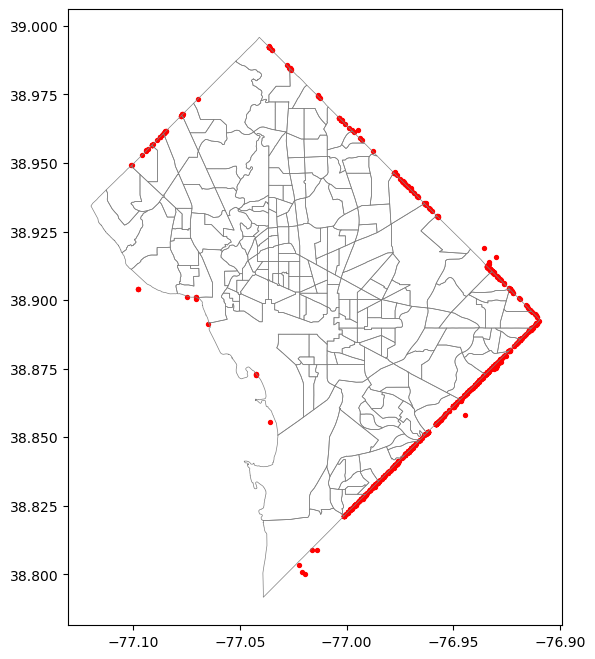

In [58]:
ax = acs_demo.boundary.plot(figsize=(8, 8), color="gray", linewidth=0.5)
crash_unmatched.plot(ax=ax, color="red", markersize=8)

A small portion of crash records (~1%) could not be spatially matched to census tracts. These unmatched points are concentrated along the DC boundary, particularly along Eastern Avenue and Southern Avenue, which form jurisdictional borders. This suggests that the mismatch is primarily due to geocoding precision and tract boundary alignment rather than data quality issues.

- Census tracts ≠ the exact boundary of Washington, DC.
- Census tracts are statistical administrative units, not precise geographic boundaries

In [64]:
# Optional quick checks

crash_panel = crash_acs.dropna(subset=["GEOID", "year", "month"]).copy()

print(f"Final match rate: {len(crash_acs) / len(crashes):.2%}")
# print(f"Final match rate: {len(crash_acs) / len(crashes_mpd):.2%}")
print("\n")
print("Missing year values after filtering:", crash_panel["year"].isna().sum())
print("\n")
print(crash_panel[["GEOID", "year", "month"]].head())

Final match rate: 30.63%


Missing year values after filtering: 0


             GEOID    year  month
986    11001009201  2019.0    7.0
58806  11001008802  2020.0   12.0
58807  11001011100  2020.0    9.0
58808  11001009905  2020.0   12.0
58809  11001009000  2021.0    1.0


We first identify unmatched crash records (i.e., those with missing ***`GEOID`***) for data quality inspection. After confirming that these unmatched cases are primarily due to boundary effects or geocoding imprecision, we recover them using a nearest spatial join.
Records are reassigned to the nearest census tract if they fall within a 150/250-meter distance threshold, improving overall data completeness while maintaining spatial accuracy.

In [65]:
# ============================================================
# Step 1: Separate matched and unmatched crash records
# ============================================================

matched = crash_acs[crash_acs["GEOID"].notna()].copy()
unmatched = crash_acs[crash_acs["GEOID"].isna()].copy()

print("Matched:", len(matched))
print("Unmatched:", len(unmatched))


# ============================================================
# Step 2: Project to meter-based CRS for nearest-distance matching
# Do NOT calculate distance in EPSG:4326
# ============================================================

matched_m = matched.to_crs(epsg=3857)
unmatched_m = unmatched.to_crs(epsg=3857)

acs_demo_m = acs_demo.to_crs(epsg=3857)


# ============================================================
# Step 3: Nearest spatial join for unmatched points only
# ============================================================

unmatched_nearest = gpd.sjoin_nearest(
    unmatched_m.drop(columns=["GEOID", "index_right"], errors="ignore"),
    acs_demo_m,
    how="left",
    distance_col="nearest_tract_dist_m"
)


# ============================================================
# Step 4: Distance threshold - only keep points within 250 meters
# ============================================================

distance_threshold = 250

unmatched_nearest = unmatched_nearest[
    unmatched_nearest["nearest_tract_dist_m"] <= distance_threshold
].copy()

print("Recovered unmatched records:", len(unmatched_nearest))


# ============================================================
# Step 5: Convert back to EPSG:4326 and combine with original matched records
# ============================================================

unmatched_nearest = unmatched_nearest.to_crs(crash_acs.crs)

crash_acs_final = pd.concat(
    [
        matched,
        unmatched_nearest[matched.columns.intersection(unmatched_nearest.columns)]
    ],
    ignore_index=True
)

print("Original crash_acs rows:", len(crash_acs))
print("Final rows:", len(crash_acs_final))
print("Remaining missing GEOID:", crash_acs_final["GEOID"].isna().sum())

Matched: 104569
Unmatched: 1055
Recovered unmatched records: 1046
Original crash_acs rows: 105624
Final rows: 105615
Remaining missing GEOID: 0


In [66]:
crash_acs_final.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 105615 entries, 0 to 105614
Data columns (total 93 columns):
 #   Column                      Non-Null Count   Dtype              
---  ------                      --------------   -----              
 0   X                           105615 non-null  float64            
 1   Y                           105615 non-null  float64            
 2   CRIMEID                     105615 non-null  int64              
 3   CCN                         105615 non-null  object             
 4   REPORTDATE                  105615 non-null  datetime64[ns, UTC]
 5   ROUTEID                     105615 non-null  object             
 6   MEASURE                     105615 non-null  float64            
 7   OFFSET                      105615 non-null  float64            
 8   STREETSEGID                 19504 non-null   float64            
 9   ROADWAYSEGID                19504 non-null   float64            
 10  FROMDATE                    105597 n

### What is `crash_acs` used for?

`crash_acs` is an intermediate crash-level dataset used to bridge raw crash records and the final tract-level panel dataset.

***NOTE***: Demographic variables are treated as time-invariant and are assumed to remain constant over the study period.

It is used for three main purposes:

---

### 1. Aggregate crash outcomes (GEOID × year × month)

Crash records are aggregated into tract-level summaries:

- **1 row = 1 GEOID × 1 year × 1 month**

This produces variables such as:

- `crash_count`
- `speeding_count`
- `fatal_driver`
- `fatal_pedestrian`
- `fatal_bicyclist`
- `major_inj_driver`
- `major_inj_ped`
- `major_inj_bike`

---

### 2. Demographic Features Already Integrated

Demographic variables from the ACS dataset have already been merged into the crash-level dataset (`crash_acs_demo`) through a spatial join.

As a result:

- Each crash record is already associated with:
  - `GEOID`
  - population and race variables
  - tract area (`area_km2`)

When aggregating to the tract level, these demographic variables can be:

- carried forward directly, or  
- merged again at the tract level if needed for consistency

---

### Why this approach?

Merging ACS data at the crash level ensures:

- consistent spatial alignment  
- no need for repeated joins later  
- a simplified and more robust data pipeline  

---

### 3. Prepare the final modeling dataset

The final tract-level panel dataset will be used for:

- regression analysis  
- crash rate calculation  
- disparity analysis  
- machine learning models  

---

## Next Step: Aggregate to Final Panel

### Step 1: Create `crash_summary`

Convert crash-level records into a tract-level panel:

- **1 row = 1 GEOID × 1 year × 1 month**

This dataset serves as the foundation for all downstream analysis.

## Aggregate Crash Records to GEOID-Year Level

After assigning each crash to a census tract, the next step is to aggregate crash records by:

- `GEOID`
- `year`
- `month`

This produces a tract-year crash summary table that can later be merged with Census demographic data using:

`on = ["GEOID", "year"]`

### Output
A panel-style crash summary table with tract-year level crash metrics.

In [67]:
crashes_mpd["REPORTDATE"].min()

Timestamp('2019-01-01 00:02:06+0000', tz='UTC')

In [68]:
crashes_mpd["REPORTDATE"].max()

Timestamp('2023-12-31 23:30:00+0000', tz='UTC')

In [69]:
import numpy as np

# ============================================================
# STEP 6: Aggregate crash metrics by GEOID, year, month 
# ============================================================

crash_summary = (
    crash_panel
    .groupby(["GEOID", "year", "month"])
    .agg(
        crash_count=("CRIMEID", "count"),
        speeding_count=("SPEEDING_INVOLVED", "sum"),
        total_vehicles=("TOTAL_VEHICLES", "sum"),
        fatal_driver=("FATAL_DRIVER", "sum"),
        fatal_pedestrian=("FATAL_PEDESTRIAN", "sum"),
        fatal_bicyclist=("FATAL_BICYCLIST", "sum"),
        major_inj_driver=("MAJORINJURIES_DRIVER", "sum"),
        major_inj_ped=("MAJORINJURIES_PEDESTRIAN", "sum"),
        major_inj_bike=("MAJORINJURIES_BICYCLIST", "sum"),

        weekend_crash = ("is_weekend", "sum"),
        night_crash = ("is_night", "sum"),
        rush_hour_crash = ("is_rush_hour", "sum")
    )
    .reset_index()
)

crash_summary["weekend_ratio"] = (
    crash_summary["weekend_crash"] / crash_summary["crash_count"]
).replace([np.inf, -np.inf], 0).fillna(0)
crash_summary["night_ratio"] = crash_summary["night_crash"] / crash_summary["crash_count"]
crash_summary["rush_hour_ratio"] = crash_summary["rush_hour_crash"] / crash_summary["crash_count"]

# Preview output
crash_summary.head()

,GEOID,year,month,crash_count,speeding_count,total_vehicles,fatal_driver,fatal_pedestrian,fatal_bicyclist,major_inj_driver,major_inj_ped,major_inj_bike,weekend_crash,night_crash,rush_hour_crash,weekend_ratio,night_ratio,rush_hour_ratio
0,11001000101,2019.0,1.0,2,0,4,0,0,0,0,0,0,0,1,0,0.000000,0.500000,0.000000
1,11001000101,2019.0,3.0,2,0,4,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000
2,11001000101,2019.0,4.0,3,0,6,0,0,0,0,0,0,1,1,1,0.333333,0.333333,0.333333
3,11001000101,2019.0,5.0,4,0,7,0,0,0,0,0,0,1,1,3,0.250000,0.250000,0.750000
4,11001000101,2019.0,6.0,3,0,6,0,0,0,0,0,0,1,1,1,0.333333,0.333333,0.333333


In [70]:
crash_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11811 entries, 0 to 11810
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   GEOID             11811 non-null  object 
 1   year              11811 non-null  float64
 2   month             11811 non-null  float64
 3   crash_count       11811 non-null  int64  
 4   speeding_count    11811 non-null  int64  
 5   total_vehicles    11811 non-null  int64  
 6   fatal_driver      11811 non-null  int64  
 7   fatal_pedestrian  11811 non-null  int64  
 8   fatal_bicyclist   11811 non-null  int64  
 9   major_inj_driver  11811 non-null  int64  
 10  major_inj_ped     11811 non-null  int64  
 11  major_inj_bike    11811 non-null  int64  
 12  weekend_crash     11811 non-null  int64  
 13  night_crash       11811 non-null  int64  
 14  rush_hour_crash   11811 non-null  int64  
 15  weekend_ratio     11811 non-null  float64
 16  night_ratio       11811 non-null  float6

In [85]:
crash_summary.columns

Index(['GEOID', 'year', 'month', 'crash_count', 'speeding_count',
       'total_vehicles', 'fatal_driver', 'fatal_pedestrian', 'fatal_bicyclist',
       'major_inj_driver', 'major_inj_ped', 'major_inj_bike', 'weekend_crash',
       'night_crash', 'rush_hour_crash', 'weekend_ratio', 'night_ratio',
       'rush_hour_ratio'],
      dtype='object')

#### CHECKLIST:

Many crashes belong to the same GEOID * year

__***Example :***__
- DC has nearly 200 tracts
- data range from 2013 ~ 2023
- 12 months a year
    - 200 * 5 * 12 = 12000 rows

## Spatial Join: Roadway and Traffic Infrastructure → Census Tracts

In this step, we spatially link roadway and traffic infrastructure datasets to census tracts.

The following datasets are included:

- `roadwayB_geo` (road segments)
- `traffic_geo` (traffic signals and controls)

---

### Key Idea

Each dataset contains geographic features (lines or points), but does not include census tract identifiers (`GEOID`).

To enable tract-level analysis, we perform a spatial join to assign each feature to a census tract.

---

### Method

- All datasets are first projected to a consistent coordinate reference system (EPSG:4326)
- Road segment lengths are calculated in a meter-based CRS (EPSG:3857)
- A spatial join (`predicate='intersects'`) is used to match:
  - road segments (lines) → tracts (polygons)
  - traffic signals (points) → tracts (polygons)

---

### Result

After the spatial join:

- Each feature is assigned a `GEOID`
- These datasets can be aggregated to the tract level
- Resulting variables will be used as explanatory features in the final panel dataset

In [73]:
# ==================================================
# Step 1: Sanity Check - CRS Check
# ==================================================

# Step 1: CRS Check
roadwayB_geo = roadwayB_geo.to_crs(epsg=4326)
# roadwayBI_geo = roadwayBI_geo.to_crs(epsg=4326)
traffic_geo = traffic_geo.to_crs(epsg=4326)

# ==================================================
# Step 2: Compute roadway length in meters
# ==================================================
roadwayB_geo_m = roadwayB_geo.to_crs(epsg=3857)
roadwayB_geo["length_m"] = roadwayB_geo_m.geometry.length
# Note: roadwayB_geo is still EPSG:4326
# but length_m was computed from EPSG:3857 coordinate systems

# ==================================================
# Step 3: Spatial join using EPSG:4326
# ==================================================
# Join every geojson file to tract level
roadB_join = gpd.sjoin(
    roadwayB_geo,
    acs_demo[["GEOID", "geometry"]],
    how="left",
    predicate="intersects"
)

# roadBI_join = gpd.sjoin(
#     roadwayBI_geo,
#     tract[["GEOID", "geometry"]],
#     how="left",
#     predicate="intersects"
# )

traffic_join = gpd.sjoin(
    traffic_geo,
    acs_demo[["GEOID", "geometry"]],
    how="left",
    predicate="intersects"
)

## 📊 Roadway Block Feature Engineering and Selection

The `Roadway_Block` dataset contains a large number of attributes describing roadway characteristics, including geometry, traffic exposure, infrastructure design, and operational features.

To ensure analytical clarity and model interpretability, a structured feature engineering and selection process is applied. Only variables with clear relevance to roadway safety and crash risk are retained.

---

### 🔹 Feature Engineering

Several binary and derived features are constructed to better capture roadway conditions:

- `has_bike_lane` → presence of bicycle infrastructure  
- `has_bus_lane` → presence of transit lanes  
- `has_parking_lane` → availability of parking lanes  
- `has_physical_buffer` → presence of raised buffers  
- `has_sidewalk_ib`, `has_sidewalk_ob` → sidewalk availability  
- `has_vertical_deflection` → traffic calming features  
- `high_speed_ob` → indicator for high-speed road segments (≥ 35 mph)  
- `effective_speed_ob` → minimum of alternative speed limit fields  

These engineered features improve interpretability and reduce noise from sparse raw variables.

---

### 🔹 Core Feature Categories

The final feature set is organized into the following categories:

---

### 🚧 Network Scale and Exposure
- `length_m`  
- `AADT`, `AADT_COMBINATION`, `AADT_SINGLE_UNIT`  

These variables capture roadway extent and traffic exposure.

---

### 🚗 Road Capacity and Geometry
- `TOTALTRAVELLANES`  
- `TOTALTRAVELLANEWIDTH`  
- `TOTALCROSSSECTIONWIDTH`  
- `TOTALTRAVELLANESINBOUND`, `TOTALTRAVELLANESOUTBOUND`  

These features describe roadway capacity and structural design.

---

### 🚲 Multimodal Infrastructure
- `TOTALBIKELANES`, `TOTALBIKELANEWIDTH`  
- `TOTALPARKINGLANES`, `TOTALPARKINGLANEWIDTH`  
- `TOTALRAISEDBUFFERS`, `TOTALRAISEDBUFFERWIDTH`  

These variables reflect multimodal design and road space allocation.

---

### 🛣️ Road Condition and Surface Quality
- `PCI_SCORE` (Pavement Condition Index)  
- `IRI` (International Roughness Index)  
- `SURFACE_TYPE`  

These features describe pavement condition and surface characteristics.

---

### 🚶 Pedestrian Environment
- `SIDEWALK_IB_WIDTH`, `SIDEWALK_OB_WIDTH`  
- `SIDEWALK_IB_PAVTYPE`, `SIDEWALK_OB_PAVTYPE`  

These variables capture pedestrian infrastructure availability.

---

### 🚦 Speed and Operational Environment
- `SPEEDLIMITS_OB`, `SPEEDLIMITS_OB_ALT`  
- `effective_speed_ob`  
- `high_speed_ob`  

These features represent the roadway speed environment.

---

### 🏷️ Functional Classification
- `FHWAFUNCTIONALCLASS`  
- `DCFUNCTIONALCLASS`  

These variables capture roadway hierarchy and classification.

---

### ⚠️ Data Quality Considerations

- The `SHAPELEN` field is excluded due to data quality issues (all values are zero)  
- Some variables (e.g., AADT components, IRI) have partial coverage and are supplemented with coverage indicators where necessary  
- Certain highly sparse or redundant variables are excluded to reduce noise  

---

### ✅ Final Output

The cleaned dataset (`roadB_v2`) contains:

- validated numeric features  
- selected categorical variables  
- engineered binary indicators  

This dataset is then aggregated to the tract level for integration into the final panel model.

In [74]:
# ====================================================
# Version 2: cleaned + validated roadway block features
# ====================================================

# -------------------------------
# 1. Create engineered features on roadB_join
# -------------------------------

roadB_join["has_vertical_deflection"] = (
    roadB_join["VERTICAL_DEFLECTION"]
    .fillna("")
    .str.strip()
    .str.upper()
    .eq("YES")
).astype(int)

roadB_join["has_bike_lane"] = (roadB_join["TOTALBIKELANES"] > 0).astype(int)

roadB_join["has_bus_lane"] = (
    roadB_join["BUSLANE_INBOUND"].notna() |
    roadB_join["BUSLANE_OUTBOUND"].notna()
).astype(int)

roadB_join["has_physical_buffer"] = (
    roadB_join["TOTALRAISEDBUFFERS"] > 0
).astype(int)

roadB_join["has_parking_lane"] = (
    roadB_join["TOTALPARKINGLANES"] > 0
).astype(int)

roadB_join["has_sidewalk_ib"] = (
    pd.to_numeric(roadB_join["SIDEWALK_IB_WIDTH"], errors="coerce") > 0
).astype(int)

roadB_join["has_sidewalk_ob"] = (
    pd.to_numeric(roadB_join["SIDEWALK_OB_WIDTH"], errors="coerce") > 0
).astype(int)

roadB_join["effective_speed_ob"] = roadB_join[
    ["SPEEDLIMITS_OB", "SPEEDLIMITS_OB_ALT"]
].min(axis=1)

roadB_join["high_speed_ob"] = (
    roadB_join["effective_speed_ob"] >= 35
).astype(int)

# Drop SHAPELEN field
roadB_join = roadB_join.drop(columns=["SHAPELEN"], errors="ignore")

# -------------------------------
# 2. Numeric features
# -------------------------------

numeric_keep_v2 = [
    # roadway length/ exposure
    "length_m",
    
    # traffic exposure / volume
    "AADT",
    "AADT_COMBINATION",
    "AADT_SINGLE_UNIT",

    # road capacity / geometry
    "TOTALTRAVELLANES",
    "TOTALTRAVELLANEWIDTH",
    "TOTALCROSSSECTIONWIDTH",
    "TOTALTRAVELLANESINBOUND",
    "TOTALTRAVELLANESOUTBOUND",

    # raised / physical buffer
    "TOTALRAISEDBUFFERS",
    "TOTALRAISEDBUFFERWIDTH",

    # parking infrastructure
    "TOTALPARKINGLANES",
    "TOTALPARKINGLANEWIDTH",

    # bicycle infrastructure
    "TOTALBIKELANES",
    "TOTALBIKELANEWIDTH",

    # pavement / road condition
    "PCI_SCORE",
    "IRI",

    # pedestrian environment
    "SIDEWALK_IB_WIDTH",
    "SIDEWALK_OB_WIDTH",

    # transit infrastructure
    "BUSLANE_INBOUND",
    "BUSLANE_OUTBOUND",

    # speed environment
    "SPEEDLIMITS_OB",
    "SPEEDLIMITS_OB_ALT",
    "effective_speed_ob"
]


# -------------------------------
# 3. Categorical features
# -------------------------------

cat_keep_v2 = [
    "SURFACE_TYPE",
    "SIDEWALK_IB_PAVTYPE",
    "SIDEWALK_OB_PAVTYPE",
    "FHWAFUNCTIONALCLASS",
    "DCFUNCTIONALCLASS"
]


# -------------------------------
# 4. Engineered binary features
# -------------------------------

engineered_cols = [
    "has_vertical_deflection",
    "has_bike_lane",
    "has_bus_lane",
    "has_physical_buffer",
    "has_parking_lane",
    "has_sidewalk_ib",
    "has_sidewalk_ob",
    "high_speed_ob"
]


# -------------------------------
# 5. Create final cleaned roadB_v2
# -------------------------------

cols_v2 = ["GEOID", "geometry", "BLOCKKEY"] + numeric_keep_v2 + cat_keep_v2 + engineered_cols

roadB_v2 = roadB_join[cols_v2].copy()

roadB_v2.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 17872 entries, 0 to 13837
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   GEOID                     17768 non-null  object  
 1   geometry                  17872 non-null  geometry
 2   BLOCKKEY                  17872 non-null  object  
 3   length_m                  17872 non-null  float64 
 4   AADT                      7239 non-null   float64 
 5   AADT_COMBINATION          4365 non-null   float64 
 6   AADT_SINGLE_UNIT          4364 non-null   float64 
 7   TOTALTRAVELLANES          17872 non-null  int32   
 8   TOTALTRAVELLANEWIDTH      17872 non-null  int32   
 9   TOTALCROSSSECTIONWIDTH    17872 non-null  int32   
 10  TOTALTRAVELLANESINBOUND   17872 non-null  int32   
 11  TOTALTRAVELLANESOUTBOUND  17872 non-null  int32   
 12  TOTALRAISEDBUFFERS        17872 non-null  int32   
 13  TOTALRAISEDBUFFERWIDTH    17872 non-null  i

## Mapping Dictionaries for Categorical Variables

The following mapping dictionaries define the meaning of coded categorical variables used in the **Roadway_Block** dataset.

These mappings are **not used directly in modeling**, but are retained for:

- Interpretation of results (e.g., SHAP, feature importance)
- Reporting and documentation
- Debugging and validation

---

### Surface Type (`SURFACE_TYPE`)

| Code | Description |
|------|------------|
| 1 | Unpaved |
| 2 | Bituminous |
| 3 | JPCP – Jointed Plain Concrete Pavement |
| 4 | JRCP – Jointed Reinforced Concrete Pavement |
| 5 | CRCP – Continuously Reinforced Concrete Pavement |
| 6 | Asphalt-Concrete (AC) Overlay over Existing AC Pavement |
| 7 | AC Overlay over Existing Jointed Concrete Pavement |
| 8 | AC Overlay over Existing CRCP |
| 9 | Unbonded Jointed Concrete Overlay on PCC Pavement |
| 10 | Bonded PCC Overlay on PCC Pavement |
| 11 | Other (e.g., whitetopping) |
| 12 | Brick |

---

### FHWA Functional Classification (`FHWAFUNCTIONALCLASS`)

| Code | Description |
|------|------------|
| 1 | Interstate |
| 2 | Principal Arterial – Other Freeways or Expressways |
| 3 | Principal Arterial – Other |
| 4 | Minor Arterial |
| 5 | Major Collector |
| 6 | Minor Collector |
| 7 | Local |

---

### DC Functional Classification (`DCFUNCTIONALCLASS`)

| Code | Description |
|------|------------|
| 11 | Interstate |
| 12 | Other Freeway and Expressway |
| 14 | Principal Arterial |
| 16 | Minor Arterial |
| 17 | Major Collector |
| 18 | Minor Collector |
| 19 | Local |

---

### Notes

- These variables are **categorical codes**, not continuous numeric values.
- During modeling, these fields are typically:
  - One-hot encoded, or
  - Target encoded (if appropriate)
- The mappings above are primarily used for **interpretation and communication**, not as model inputs.

In [76]:
# ====================================================
# Mapping dictionaries
# ====================================================

roadB_v2["SURFACE_TYPE_clean"] = (
    roadB_v2["SURFACE_TYPE"]
    .replace(0, pd.NA) # 0->NaN, NaN->NaN
    .fillna(-1) # 0->(-1), NaN->(-1)
)

roadB_v2["FHWAFUNCTIONALCLASS_clean"] = (
    roadB_v2["FHWAFUNCTIONALCLASS"]
    .replace(0, pd.NA) # 0->NaN, NaN->NaN
    .fillna(-1) # 0->(-1), NaN->(-1)
)

roadB_v2["DCFUNCTIONALCLASS_clean"] = (
    roadB_v2["DCFUNCTIONALCLASS"]
    .replace(0, pd.NA) # 0->NaN, NaN->NaN
    .fillna(-1) # 0->(-1), NaN->(-1)
)

surface_type_map = {
    -1:"Unknown",
    1: "Unpaved",
    2: "Bituminous",
    3: "JPCP - Jointed Plain Concrete Pavement",
    4: "JRCP - Jointed Reinforced Concrete Pavement",
    5: "CRCP - Continuously Reinforced Concrete Pavement",
    6: "AC Overlay over Existing AC Pavement",
    7: "AC Overlay over Existing Jointed Concrete Pavement",
    8: "AC Overlay over Existing CRCP",
    9: "Unbonded Jointed Concrete Overlay on PCC Pavement",
    10: "Bonded PCC Overlay on PCC Pavement",
    11: "Other",
    12: "Brick"
}

fhwa_class_map = {
    -1:"Unknown",
    1: "Interstate",
    2: "Principal Arterial - Other Freeways or Expressways",
    3: "Principal Arterial - Other",
    4: "Minor Arterial",
    5: "Major Collector",
    6: "Minor Collector",
    7: "Local"
}

dc_class_map = {
    -1:"Unknown",
    11: "Interstate",
    12: "Other Freeway and Expressway",
    14: "Principal Arterial",
    16: "Minor Arterial",
    17: "Major Collector",
    18: "Minor Collector",
    19: "Local"
}

/var/folders/vl/d4jp3x4n6pvgdsw9fp1v7m6h0000gn/T/ipykernel_1701/3144764898.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(-1) # 0->(-1), NaN->(-1)


In [77]:
def first_mode(s):
    """
    Return the most frequent non-missing value within a group.

    This function is designed to be used inside a groupby().agg() operation,
    especially for categorical variables.

    Parameters
    ----------
    s : pandas Series
        A subset of one column for one group.
        For example, after groupby("GEOID"), s represents all values of a
        categorical variable within one census tract.

    Logic
    -----
    1. s.mode(dropna=True) finds the most frequently occurring value(s)
       in the group, while ignoring missing values.

    2. The result of .mode() can contain more than one value if there is a tie.
       For example, if values [2, 2, 3, 3] appear in one group, both 2 and 3
       are modes.

    3. Since groupby().agg() expects one output value per group, this function
       selects the first mode using m.iloc[0].

    4. If the group contains only missing values, .mode(dropna=True) returns
       an empty Series. In that case, the function returns pd.NA instead of
       causing an error.

    Returns
    -------
    A single value:
        - the most common non-missing value in the group, or
        - pd.NA if no non-missing value exists.
    """

    # Compute the mode, meaning the most frequently occurring value(s),
    # while ignoring missing values.
    m = s.mode(dropna=True)

    # If at least one mode exists, return the first one.
    # If multiple values tie as the most frequent, this selects the first.
    # If no valid value exists, return pd.NA.
    return m.iloc[0] if len(m) > 0 else pd.NA


roadB_agg = (
    roadB_v2
    .dropna(subset=["GEOID"])
    .groupby("GEOID", as_index=False) # GEOID remains as a regular column and is not converted into the DataFrame index
    .agg(
        # =====================
        # Exposure / scale
        # =====================
        road_segment_count=("BLOCKKEY", "nunique"),
        road_total_length_m=("length_m", "sum"),
        avg_segment_length_m=("length_m", "mean"),

        # =====================
        # Traffic exposure
        # =====================
        mean_aadt=("AADT", "mean"),
        mean_aadt_combination=("AADT_COMBINATION", "mean"),
        mean_aadt_single_unit=("AADT_SINGLE_UNIT", "mean"),

        # =====================
        # Road geometry / capacity
        # =====================
        total_travel_lanes_sum=("TOTALTRAVELLANES", "sum"),
        avg_travel_lanes=("TOTALTRAVELLANES", "mean"),

        total_travel_lane_width_sum=("TOTALTRAVELLANEWIDTH", "sum"),
        avg_travel_lane_width=("TOTALTRAVELLANEWIDTH", "mean"),

        total_cross_section_width_sum=("TOTALCROSSSECTIONWIDTH", "sum"),
        avg_cross_section_width=("TOTALCROSSSECTIONWIDTH", "mean"),

        total_lanes_inbound_sum=("TOTALTRAVELLANESINBOUND", "sum"),
        avg_lanes_inbound=("TOTALTRAVELLANESINBOUND", "mean"),

        total_lanes_outbound_sum=("TOTALTRAVELLANESOUTBOUND", "sum"),
        avg_lanes_outbound=("TOTALTRAVELLANESOUTBOUND", "mean"),

        # =====================
        # Bike / parking / buffer infrastructure
        # =====================
        total_bike_lanes_sum=("TOTALBIKELANES", "sum"),
        avg_bike_lanes=("TOTALBIKELANES", "mean"),
        total_bike_lane_width_sum=("TOTALBIKELANEWIDTH", "sum"),
        avg_bike_lane_width=("TOTALBIKELANEWIDTH", "mean"),

        total_parking_lanes_sum=("TOTALPARKINGLANES", "sum"),
        avg_parking_lanes=("TOTALPARKINGLANES", "mean"),
        total_parking_lane_width_sum=("TOTALPARKINGLANEWIDTH", "sum"),
        avg_parking_lane_width=("TOTALPARKINGLANEWIDTH", "mean"),

        total_raised_buffers_sum=("TOTALRAISEDBUFFERS", "sum"),
        avg_raised_buffers=("TOTALRAISEDBUFFERS", "mean"),
        total_raised_buffer_width_sum=("TOTALRAISEDBUFFERWIDTH", "sum"),
        avg_raised_buffer_width=("TOTALRAISEDBUFFERWIDTH", "mean"),

        # =====================
        # Road condition
        # =====================
        mean_pci_score=("PCI_SCORE", "mean"),
        mean_iri=("IRI", "mean"),

        # =====================
        # Speed environment
        # =====================
        mean_speedlimit_ob=("SPEEDLIMITS_OB", "mean"),
        mean_speedlimit_ob_alt=("SPEEDLIMITS_OB_ALT", "mean"),
        mean_effective_speed_ob=("effective_speed_ob", "mean"),

        # =====================
        # Infrastructure coverage ratios
        # mean of binary columns = proportion of road segments with that feature
        # =====================
        bike_lane_ratio=("has_bike_lane", "mean"),
        bus_lane_ratio=("has_bus_lane", "mean"),
        buffer_ratio=("has_physical_buffer", "mean"),
        parking_lane_ratio=("has_parking_lane", "mean"),
        sidewalk_ib_ratio=("has_sidewalk_ib", "mean"),
        sidewalk_ob_ratio=("has_sidewalk_ob", "mean"),
        high_speed_ratio=("high_speed_ob", "mean"),
        vertical_deflection_ratio=("has_vertical_deflection", "mean"),

        # =====================
        # Classification / categorical features
        # =====================
        surface_type_mode=("SURFACE_TYPE_clean", first_mode),
        sidewalk_ib_pavtype_mode=("SIDEWALK_IB_PAVTYPE", first_mode),
        sidewalk_ob_pavtype_mode=("SIDEWALK_OB_PAVTYPE", first_mode),
        fhwa_class_mode=("FHWAFUNCTIONALCLASS_clean", first_mode),
        dc_class_mode=("DCFUNCTIONALCLASS_clean", first_mode)
    )
)

In [79]:
# ===========================================
# Decode categorical mode values after aggregation
# ===========================================

roadB_agg["surface_type_mode_label"] = (
    roadB_agg["surface_type_mode"].map(surface_type_map)
)

roadB_agg["fhwa_class_mode_label"] = (
    roadB_agg["fhwa_class_mode"].map(fhwa_class_map)
)

roadB_agg["dc_class_mode_label"] = (
    roadB_agg["dc_class_mode"].map(dc_class_map)
)

In [81]:
roadB_agg["iri_coverage_ratio"] = (
    roadB_v2
    .groupby("GEOID")["IRI"]
    .apply(lambda x: x.notna().mean())
    .values
)

roadB_agg["surface_coverage_ratio"] = (
    roadB_v2
    .groupby("GEOID")["SURFACE_TYPE"]
    .apply(lambda x: x.notna().mean())
    .values
)

# roadB_agg['surface_coverage_ratio'].unique()
# roadB_agg["iri_coverage_ratio"].unique()

In [82]:
roadB_agg.head()

,GEOID,road_segment_count,road_total_length_m,avg_segment_length_m,mean_aadt,mean_aadt_combination,mean_aadt_single_unit,total_travel_lanes_sum,avg_travel_lanes,total_travel_lane_width_sum,...,surface_type_mode,sidewalk_ib_pavtype_mode,sidewalk_ob_pavtype_mode,fhwa_class_mode,dc_class_mode,surface_type_mode_label,fhwa_class_mode_label,dc_class_mode_label,iri_coverage_ratio,surface_coverage_ratio
0,11001000101,36,7249.050473,201.362513,9280.333333,63.500000,147.000000,75,2.083333,661,...,-1.0,12 (Brick),12 (Brick),7.0,19.0,Unknown,Local,Local,0.416667,1.000000
1,11001000102,149,29903.795319,200.696613,12903.112903,184.032258,679.774194,320,2.147651,3117,...,-1.0,12 (Brick),12 (Brick),7.0,19.0,Unknown,Local,Local,0.557047,1.000000
2,11001000201,38,6825.777289,179.625718,7803.000000,NaN,NaN,57,1.500000,627,...,-1.0,3 (JPCP),12 (Brick),7.0,19.0,Unknown,Local,Local,0.184211,0.973684
3,11001000202,141,23318.092163,165.376540,10857.875000,203.791667,738.625000,282,2.000000,2875,...,-1.0,12 (Brick),12 (Brick),7.0,19.0,Unknown,Local,Local,0.567376,0.992908
4,11001000300,148,20340.021710,137.432579,5607.483871,72.769231,230.692308,265,1.790541,2670,...,-1.0,3 (JPCP),3 (JPCP),7.0,19.0,Unknown,Local,Local,0.256757,1.000000


In [83]:
roadB_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 52 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   GEOID                          206 non-null    object 
 1   road_segment_count             206 non-null    int64  
 2   road_total_length_m            206 non-null    float64
 3   avg_segment_length_m           206 non-null    float64
 4   mean_aadt                      206 non-null    float64
 5   mean_aadt_combination          203 non-null    float64
 6   mean_aadt_single_unit          203 non-null    float64
 7   total_travel_lanes_sum         206 non-null    int32  
 8   avg_travel_lanes               206 non-null    float64
 9   total_travel_lane_width_sum    206 non-null    int32  
 10  avg_travel_lane_width          206 non-null    float64
 11  total_cross_section_width_sum  206 non-null    int32  
 12  avg_cross_section_width        206 non-null    flo

### ⚠️ Note on Information Loss from Mode Aggregation

During the aggregation step, several categorical variables (e.g., `FHWAFUNCTIONALCLASS`, `DCFUNCTIONALCLASS`, `SURFACE_TYPE`, and sidewalk pavement types) are summarized using the **mode** (most frequent value) within each census tract (`GEOID`).

While this approach provides a simple representation of the *dominant* roadway characteristic in each tract, it introduces **information loss**:

- The mode only captures the **most common category**, ignoring all other values present within the tract.
- As a result, **less frequent but potentially important categories** (e.g., highways or arterial roads) may be completely excluded from the aggregated dataset.
- This can lead to a situation where:
  - A tract that contains a mix of local roads, arterials, and highways is represented only by the most frequent class (often “Local”).
  - The presence of high-speed or high-risk road types is not reflected in the final features.

#### Example:
If a tract contains:
- 70% Local roads (class 7)
- 20% Minor Arterial (class 4)
- 10% Highway (class 1)

After aggregation using mode:
- `fhwa_class_mode = 7` (Local)

This masks the existence of arterial and highway segments, which may be critical for modeling crash risk.

#### Implication:
The use of mode simplifies categorical data but may **underrepresent heterogeneity in roadway infrastructure**, potentially weakening the model’s ability to capture risk factors associated with less frequent but impactful road types.

#### Future Improvement:
To better capture roadway composition, additional features such as:
- Proportion of road types (e.g., highway_ratio, arterial_ratio)
- Length-weighted distributions

can be incorporated alongside the mode.

In [89]:
# Merge roadwayB_geo/roadwayBI_geo/traffic_geo in the panel
panel = crash_summary.merge(roadB_agg, on="GEOID", how="left")

panel = panel.merge(
    acs_demo.drop(columns="geometry"),
    on="GEOID",
    how="left"
)

panel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11811 entries, 0 to 11810
Data columns (total 86 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   GEOID                          11811 non-null  object 
 1   year                           11811 non-null  float64
 2   month                          11811 non-null  float64
 3   crash_count                    11811 non-null  int64  
 4   speeding_count                 11811 non-null  int64  
 5   total_vehicles                 11811 non-null  int64  
 6   fatal_driver                   11811 non-null  int64  
 7   fatal_pedestrian               11811 non-null  int64  
 8   fatal_bicyclist                11811 non-null  int64  
 9   major_inj_driver               11811 non-null  int64  
 10  major_inj_ped                  11811 non-null  int64  
 11  major_inj_bike                 11811 non-null  int64  
 12  weekend_crash                  11811 non-null 

In [94]:
print("Rows before merge:", len(crash_summary))
print("Rows after merge:", len(panel))

panel.isna().mean().sort_values(ascending=False).head(10)

Rows before merge: 11811
Rows after merge: 11811


mean_speedlimit_ob_alt      0.096774
mean_aadt_combination       0.013716
mean_aadt_single_unit       0.013716
mean_iri                    0.000000
high_speed_ratio            0.000000
surface_type_mode_label     0.000000
dc_class_mode               0.000000
fhwa_class_mode             0.000000
sidewalk_ob_pavtype_mode    0.000000
sidewalk_ib_pavtype_mode    0.000000
dtype: float64

In [96]:
# Traffic Signals - ACS tract level join
# Traffic Signals aggreation

for col in [
    "LPI", "NTOR_SIGNAGE", "ALL_PED_PHASE", "BIKE_PHASE",
    "QUEUE_JUMP", "TRANSIT_SIGNAL_PRIORITY", "PED_RECALL_MODE",
    "HAWK", "APS"
]:
    traffic_join[col] = traffic_join[col].where(
        traffic_join[col].isna(),
        traffic_join[col].astype(str).str.strip().str.lower()
    )

# ====================================================
# traffic_geo -> GEOID-level aggregation
# ====================================================

traffic_agg = (
    traffic_join
    .dropna(subset=["GEOID"])
    .groupby("GEOID", as_index=False)
    .agg(
        # =============================
        # Base
        # =============================
        traffic_ct=("INTERSECTIONKEY", "size"),
        traffic_intersection_ct=("INTERSECTIONKEY", "nunique"),

        # =============================
        # Numerical
        # =============================
        acisa_sum=("ACISA", "sum"), # Adaptive / Coordinated Intersection Signal Attribute？
        acisa_mean=("ACISA", "mean"),

        # =============================
        # Feature signals
        # =============================
        lpi_ct=("LPI", lambda s: (s == "yes").sum()), # Leading Pedestrian Interval
        ntor_ct=("NTOR_SIGNAGE", lambda s: (s == "completed").sum()), # No Turn on Red Signage
        all_ped_phase_ct=("ALL_PED_PHASE", lambda s: s.isin(["all-ped phase"]).sum()), # All-Pedestrian Phase / Exclusive Pedestrian Phase
        bike_phase_ct=("BIKE_PHASE", lambda s: (s == "completed").sum()), # Bicycle Signal Phase
        queue_jump_ct=("QUEUE_JUMP", lambda s: (s == "yes").sum()), # Queue Jump Lane / Signal Priority Phase 
        tsp_ct=("TRANSIT_SIGNAL_PRIORITY", lambda s: (s == "yes").sum()), 
        hawk_ct=("HAWK", lambda s: (s == "yes").sum()), # High-Intensity Activated Crosswalk Beacon
        aps_installed_ct=("APS", lambda s: (s == "yes").sum()), # Accessible Pedestrian Signals
        aps_planned_ct=("APS", lambda s: (s == "planned").sum()),

        # =============================
        # ped signal complexity
        # =============================
        ped_signal_mode_ct=("PED_RECALL_MODE", lambda s: s.isin([
            "recall", "tod recall", "actuated"
        ]).sum())
    )
)

traffic_agg.head()

,GEOID,traffic_ct,traffic_intersection_ct,acisa_sum,acisa_mean,lpi_ct,ntor_ct,all_ped_phase_ct,bike_phase_ct,queue_jump_ct,tsp_ct,hawk_ct,aps_installed_ct,aps_planned_ct,ped_signal_mode_ct
0,11001000102,8,8,48466,6058.250000,8,6,1,0,0,1,0,1,0,8
1,11001000201,2,2,12072,6036.000000,2,0,0,0,0,0,0,2,0,2
2,11001000202,17,16,104399,6141.117647,13,11,0,0,0,0,0,2,0,17
3,11001000300,2,2,12418,6209.000000,2,0,0,0,0,0,0,1,0,2
4,11001000400,13,12,79398,6107.538462,10,7,0,0,0,4,0,2,0,12


In [97]:
traffic_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   GEOID                    200 non-null    object 
 1   traffic_ct               200 non-null    int64  
 2   traffic_intersection_ct  200 non-null    int64  
 3   acisa_sum                200 non-null    int32  
 4   acisa_mean               200 non-null    float64
 5   lpi_ct                   200 non-null    int64  
 6   ntor_ct                  200 non-null    int64  
 7   all_ped_phase_ct         200 non-null    int64  
 8   bike_phase_ct            200 non-null    int64  
 9   queue_jump_ct            200 non-null    int64  
 10  tsp_ct                   200 non-null    int64  
 11  hawk_ct                  200 non-null    int64  
 12  aps_installed_ct         200 non-null    int64  
 13  aps_planned_ct           200 non-null    int64  
 14  ped_signal_mode_ct       2

In [98]:
# ====================================================
# traffic_geo -> join into panel
# ====================================================

panel = panel.merge(traffic_agg, on="GEOID", how="left")
panel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11811 entries, 0 to 11810
Data columns (total 100 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   GEOID                          11811 non-null  object 
 1   year                           11811 non-null  float64
 2   month                          11811 non-null  float64
 3   crash_count                    11811 non-null  int64  
 4   speeding_count                 11811 non-null  int64  
 5   total_vehicles                 11811 non-null  int64  
 6   fatal_driver                   11811 non-null  int64  
 7   fatal_pedestrian               11811 non-null  int64  
 8   fatal_bicyclist                11811 non-null  int64  
 9   major_inj_driver               11811 non-null  int64  
 10  major_inj_ped                  11811 non-null  int64  
 11  major_inj_bike                 11811 non-null  int64  
 12  weekend_crash                  11811 non-null

In [100]:
import os

auto_claims_dc = panel.copy()
data_path = os.path.join("..", "..", "..", "Data", "auto_claims_dc.csv")

auto_claims_dc.to_csv(data_path, index=False)